<a href="https://colab.research.google.com/github/Asmitx026/AI-Lab/blob/main/assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Q. Predict values for a simple dataset using Decision Tree Classifier along with visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

df = pd.DataFrame({
    'X': [1,1,0,1],
    'Y': [1,1,0,0],
    'Z': [1,0,1,0],
    'Class': ['I','I','II','II']
})

X = df[['X','Y','Z']]
y = df['Class']

model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
model.fit(X,y)

DecisionTreeClassifier(criterion='entropy', random_state=42)

Dataset: 
   X  Y  Z Class
0  1  1  1     I
1  1  1  0     I
2  0  0  1    II
3  1  0  0    II

Information Gain:
X = 0.0
Y = 1.0
Z = 0.0

Actual Classes: ['I', 'I', 'II', 'II']
Predicted Classes: ['I' 'I' 'II' 'II']



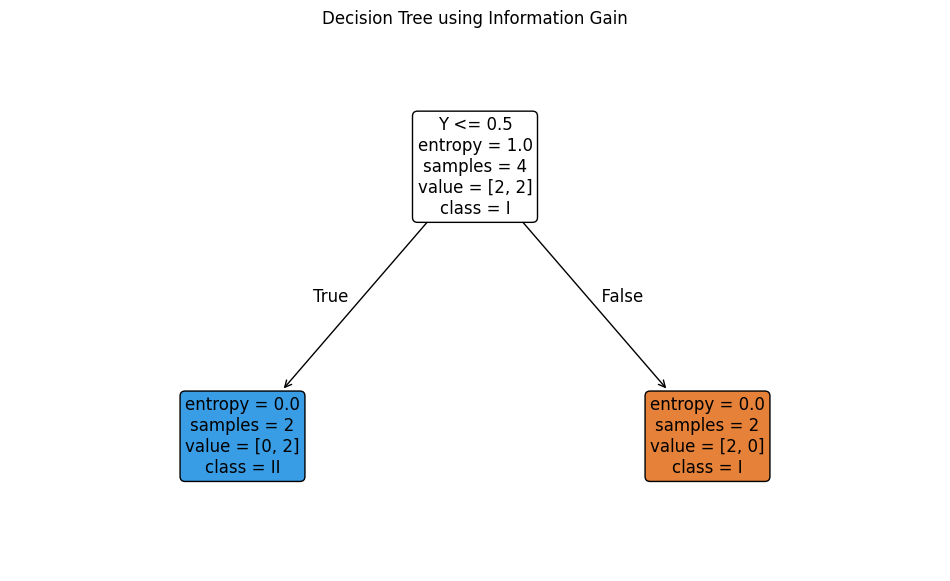

In [ ]:
print(f"Dataset: \n{df}")

y_pred = model.predict(X)

print("\nInformation Gain:")
for feature, importance in zip(X.columns,model.feature_importances_):
    print(feature, "=", round(importance, 4))

print(f"\nActual Classes: {list(y)}")
print(f"Predicted Classes: {y_pred}\n")

plt.figure(figsize=(12,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree using Information Gain")
plt.show()

### Q. Iris Dataset Classification using Decision Tree

In [13]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
iris = sns.load_dataset('iris')

print(f"Dataset: \n{iris}")
print("\nDataset Information:")
print(df.info())
print(f"\nStatistical Information: \n{iris.describe()}")

print(f"\nColumn names: {list(iris.columns)}")
print(f"Dataaset Shape: {iris.shape}")
print(f"\nClass Distribution: {iris['species'].value_counts()}")

Dataset: 
     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non

In [26]:
X = iris[[
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width'
]]
y = iris['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [27]:
model=DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [31]:
y_pred = model.predict(X_test)
print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {round(accuracy*100,2)}%")

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)


Actual Values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']

Predicted Values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']

Accuracy: 93.33%
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy  

[Text(0, 0.5, 'setosa'), Text(0, 1.5, 'versicolor'), Text(0, 2.5, 'virginica')]

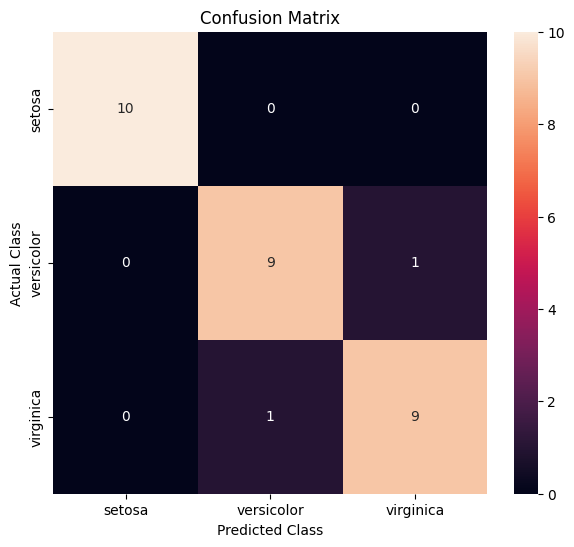

In [39]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, cbar=True, ax=ax)
ax.set_title("Confusion Matrix")

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_xticklabels(model.classes_)
ax.set_yticklabels(model.classes_)

sepal_length: 0.0066
sepal_width: 0.0146
petal_length: 0.672
petal_width: 0.3068


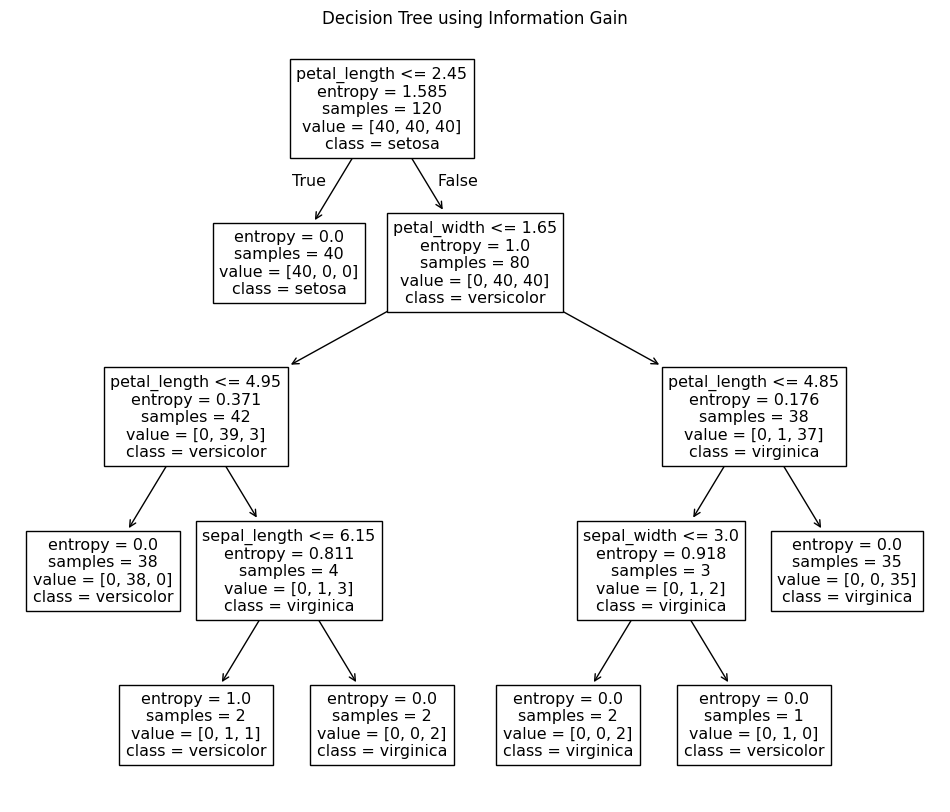

In [41]:
for feature,importance in zip(X.columns, model.feature_importances_):
    print(f"{feature}: {round(importance,4)}")

plt.figure(figsize=(12,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_
)
plt.title("Decision Tree using Information Gain")
plt.show()